# 🔷 COMPLETE DATA ANALYSIS PIPELINE

# Import Libraries

In [32]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load Dataset & Initial Inspection

In [33]:
# Load dataset
df = pd.read_csv("world_population.csv")


In [34]:
# View first rows
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [35]:
# View last rows
df.tail()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
229,226,WLF,Wallis and Futuna,Mata-Utu,Oceania,11572,11655,12182,13142,14723,13454,11315,9377,142,81.4930,0.9953,0.00
230,172,ESH,Western Sahara,El Aaiún,Africa,575986,556048,491824,413296,270375,178529,116775,76371,266000,2.1654,1.0184,0.01
231,46,YEM,Yemen,Sanaa,Asia,33696614,32284046,28516545,24743946,18628700,13375121,9204938,6843607,527968,63.8232,1.0217,0.42
232,63,ZMB,Zambia,Lusaka,Africa,20017675,18927715,16248230,13792086,9891136,7686401,5720438,4281671,752612,26.5976,1.0280,0.25
233,74,ZWE,Zimbabwe,Harare,Africa,16320537,15669666,14154937,12839771,11834676,10113893,7049926,5202918,390757,41.7665,1.0204,0.20


In [36]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [37]:
# Check missing values
df.isnull().sum()

Rank                           0
CCA3                           0
Country/Territory              0
Capital                        0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population                0
2000 Population                0
1990 Population                0
1980 Population                0
1970 Population                0
Area (km²)                     0
Density (per km²)              0
Growth Rate                    0
World Population Percentage    0
dtype: int64

In [38]:
# Statistical summary
df.describe()

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234.000000,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,234.000000,234.000000,234.000000
mean,117.500000,3.407441e+07,3.350107e+07,3.172996e+07,2.984524e+07,2.626947e+07,2.271022e+07,1.898462e+07,1.578691e+07,5.814494e+05,452.127044,1.009577,0.427051
std,67.694165,1.367664e+08,1.355899e+08,1.304050e+08,1.242185e+08,1.116982e+08,9.783217e+07,8.178519e+07,6.779509e+07,1.761841e+06,2066.121904,0.013385,1.714977
min,1.000000,5.100000e+02,5.200000e+02,5.640000e+02,5.960000e+02,6.510000e+02,7.000000e+02,7.330000e+02,7.520000e+02,1.000000e+00,0.026100,0.912000,0.000000
25%,59.250000,4.197385e+05,4.152845e+05,4.046760e+05,3.931490e+05,3.272420e+05,2.641158e+05,2.296142e+05,1.559970e+05,2.650000e+03,38.417875,1.001775,0.010000
50%,117.500000,5.559944e+06,5.493074e+06,5.307400e+06,4.942770e+06,4.292907e+06,3.825410e+06,3.141146e+06,2.604830e+06,8.119950e+04,95.346750,1.007900,0.070000
75%,175.750000,2.247650e+07,2.144798e+07,1.973085e+07,1.915957e+07,1.576230e+07,1.186923e+07,9.826054e+06,8.817329e+06,4.304258e+05,238.933250,1.016950,0.280000
max,234.000000,1.425887e+09,1.424930e+09,1.393715e+09,1.348191e+09,1.264099e+09,1.153704e+09,9.823725e+08,8.225344e+08,1.709824e+07,23172.266700,1.069100,17.880000


# Outlier Detection

A) 2022 Population

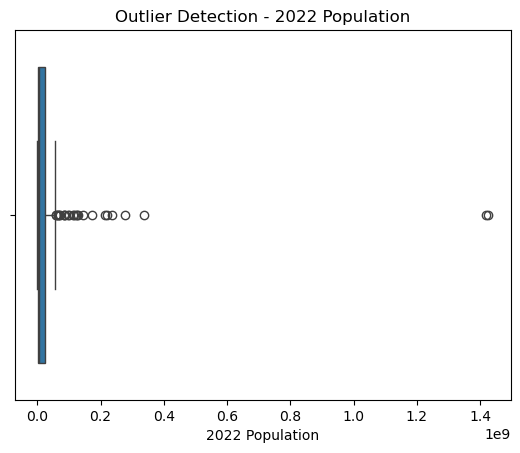

In [39]:
plt.figure()
sns.boxplot(x=df["2022 Population"])
plt.title("Outlier Detection - 2022 Population")
plt.show()

B) Density

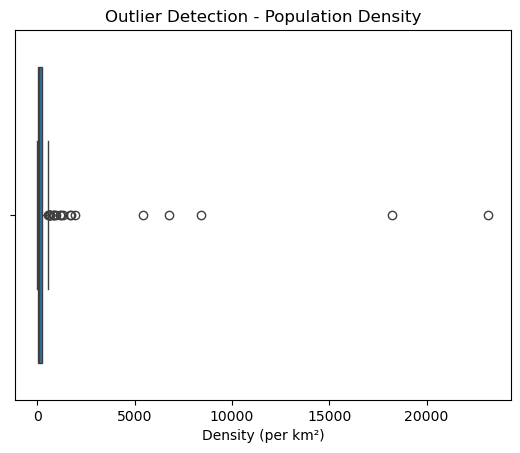

In [40]:
plt.figure()
sns.boxplot(x=df["Density (per km²)"])
plt.title("Outlier Detection - Population Density")
plt.show()

C) Growth Rate

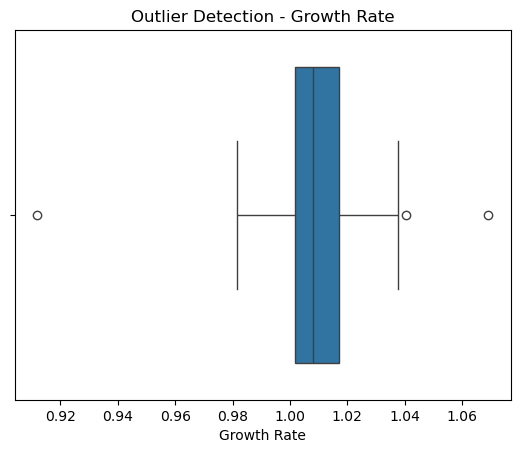

In [41]:
plt.figure()
sns.boxplot(x=df["Growth Rate"])
plt.title("Outlier Detection - Growth Rate")
plt.show()

# Statistical Outlier Detection (IQR Method)

In [42]:
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    
    return outliers

Apply to 2022 Population

In [43]:
population_outliers = detect_outliers_iqr(df["2022 Population"])
df[df["2022 Population"].isin(population_outliers)][
    ["Country/Territory", "2022 Population"]
]

,Country/Territory,2022 Population
16,Bangladesh,171186372
27,Brazil,215313498
41,China,1425887337
55,DR Congo,99010212
57,Egypt,110990103
63,Ethiopia,123379924
68,France,64626628
74,Germany,83369843
92,India,1417173173
93,Indonesia,275501339


Apply to Density

In [44]:
density_outliers = detect_outliers_iqr(df["Density (per km²)"])
df[df["Density (per km²)"].isin(density_outliers)][
    ["Country/Territory", "Density (per km²)"]
]

,Country/Territory,Density (per km²)
10,Aruba,591.3611
15,Bahrain,1924.4876
16,Bangladesh,1160.0350
17,Barbados,654.9651
22,Bermuda,1188.5926
76,Gibraltar,5441.5000
83,Guernsey,811.5513
89,Hong Kong,6783.3922
103,Jersey,954.9828
119,Macau,23172.2667


Apply to Growth Rate

In [45]:
growth_outliers = detect_outliers_iqr(df["Growth Rate"])
df[df["Growth Rate"].isin(growth_outliers)][
    ["Country/Territory", "Growth Rate"]
]

,Country/Territory,Growth Rate
133,Moldova,1.0691
164,Poland,1.0404
218,Ukraine,0.9120


There are no wrong or errors , all are genuine outliers 

# Save Exact Original Copy (Without Any Modification)

In [46]:
# ===============================
# Create Backup of Original Dataset
# ===============================

df_original = pd.read_csv("world_population.csv")

# Save exact untouched copy
df_original.to_csv("world_population_backup_original.csv", index=False)

print("Backup file created successfully.")

Backup file created successfully.


# Data to Time-Series Format (Panel Structure)

In [49]:
# ===============================
# STEP 3: Convert Wide → Long Format
# ===============================

population_cols = [
    "1970 Population", "1980 Population", "1990 Population",
    "2000 Population", "2010 Population",
    "2015 Population", "2020 Population", "2022 Population"
]

df_long = df.melt(
    id_vars=["Country/Territory", "Continent", "Area (km²)", "Growth Rate"],
    value_vars=population_cols,
    var_name="Year",
    value_name="Population"
)

# Extract numeric year properly
df_long["Year"] = df_long["Year"].str.extract("(\d+)").astype(int)

# Create relative year index
df_long["Year_Index"] = df_long["Year"] - 1970

# Sort properly
df_long.sort_values(["Country/Territory", "Year"], inplace=True)

df_long.head()

,Country/Territory,Continent,Area (km²),Growth Rate,Year,Population,Year_Index
0,Afghanistan,Asia,652230,1.0257,1970,10752971,0
234,Afghanistan,Asia,652230,1.0257,1980,12486631,10
468,Afghanistan,Asia,652230,1.0257,1990,10694796,20
702,Afghanistan,Asia,652230,1.0257,2000,19542982,30
936,Afghanistan,Asia,652230,1.0257,2010,28189672,40


# Advanced Feature Engineering (Lag + Growth Features)

In [61]:
# ===============================
# STEP 4: Create Time-Based Features
# ===============================

# Log transformation (stabilize variance)
df_long["Log_Population"] = np.log1p(df_long["Population"])

# Lag feature (previous decade population)
df_long.sort_values(["Country/Territory", "Year"], inplace=True)
df_long["Lag_Population"] = df_long.groupby("Country/Territory")["Log_Population"].shift(1)

# Growth between decades
df_long["Growth_Rate_Decade"] = (
    df_long["Log_Population"] - df_long["Lag_Population"]
)

# Drop first decade rows (no lag)
df_long = df_long.dropna()

# Encode Categorical Variables

In [62]:
# ===============================
# STEP 5: Encode Continent
# ===============================

le = LabelEncoder()
df_long["Continent_Encoded"] = le.fit_transform(df_long["Continent"])

# Define Features & Target

We predict next population value using lag

In [63]:
# ===============================
# STEP 6: Define Features
# ===============================

features = [
    "Lag_Population",
    "Year_Index",
    "Continent_Encoded",
    "Area (km²)"
]

X = df_long[features]
y = df_long["Log_Population"]

# Time-Aware Train-Test Split

Instead of random split:

Train: up to 2015
Test: 2020 & 2022

In [64]:
# ===============================
# STEP 7: Time-Based Split
# ===============================

train = df_long[df_long["Year"] <= 2015]
test = df_long[df_long["Year"].isin([2020, 2022])]

# ===============================
# Additional Time-Based Validation
# ===============================

# Validation 1: Train <= 2000, Test = 2010
train_1 = df_long[df_long["Year"] <= 2000]
test_1 = df_long[df_long["Year"] == 2010]

# Validation 2: Train <= 2010, Test = 2015
train_2 = df_long[df_long["Year"] <= 2010]
test_2 = df_long[df_long["Year"] == 2015]

X_train = train[features]
y_train = train["Log_Population"]

X_test = test[features]
y_test = test["Log_Population"]

# Train Advanced Model (XGBoost)

In [65]:
# ===============================
# Import XGBoost
# ===============================
from xgboost import XGBRegressor

# ===============================
# STEP 8: Train XGBoost Model
# ===============================

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

# Evaluate Model Properly

In [66]:
# ===============================
# STEP 9: Model Evaluation
# ===============================

from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

y_pred_log = model.predict(X_test)

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("MAPE:", mean_absolute_percentage_error(y_test_actual, y_pred_actual))
print("R2:", r2_score(y_test_actual, y_pred_actual))

test_results = test.copy()

test_results["Actual"] = np.expm1(y_test)
test_results["Predicted"] = np.expm1(model.predict(X_test))

print(test_results[["Country/Territory", "Actual", "Predicted"]].head())

MAE: 1798556.4332090232
MAPE: 0.056977533623574834
R2: 0.9963914402475162
     Country/Territory      Actual    Predicted
1404       Afghanistan  38972230.0  38723240.00
1638       Afghanistan  41128771.0  44685176.00
1405           Albania   2866849.0   2900546.75
1639           Albania   2842321.0   2901360.25
1406           Algeria  43451666.0  42653208.00


This tells us:

How accurate predictions are

How well the model generalizes across decades

In [67]:
# ===============================
# Error Analysis by Country Size
# ===============================

test = test.copy()
test["Actual"] = y_test_actual
test["Predicted"] = y_pred_actual
test["Absolute_Error"] = abs(test["Actual"] - test["Predicted"])

# Check largest countries
print(test.sort_values("Actual", ascending=False).head(10))

# Check smallest countries
print(test.sort_values("Actual", ascending=True).head(10))

     Country/Territory      Continent  Area (km²)  Growth Rate  Year  \
1679             China           Asia     9706961       1.0000  2022   
1445             China           Asia     9706961       1.0000  2020   
1730             India           Asia     3287590       1.0068  2022   
1496             India           Asia     3287590       1.0068  2020   
1859     United States  North America     9372610       1.0038  2022   
1625     United States  North America     9372610       1.0038  2020   
1731         Indonesia           Asia     1904569       1.0064  2022   
1497         Indonesia           Asia     1904569       1.0064  2020   
1794          Pakistan           Asia      881912       1.0191  2022   
1560          Pakistan           Asia      881912       1.0191  2020   

      Population  Year_Index  Log_Population  Lag_Population  \
1679  1425887337          52       21.078060       21.077388   
1445  1424929781          50       21.077388       21.055239   
1730  141717317

This shows whether model favors large nations.

# Feature Importance (Key Drivers)

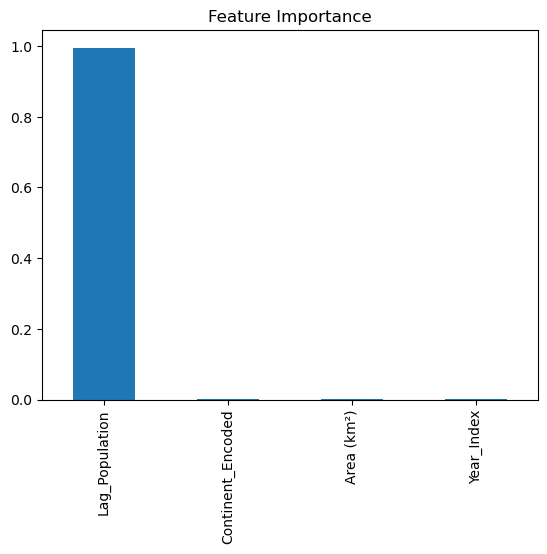

In [68]:
# ===============================
# STEP 10: Feature Importance
# ===============================

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

This answers:

What influences population most?

Usually:

Lag_Population

Growth Rate

Year

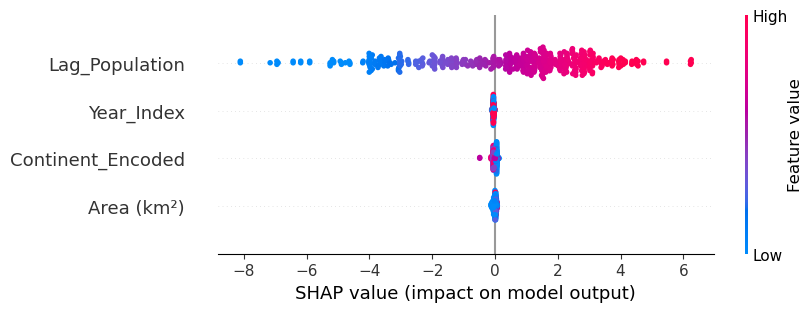

In [69]:
# ===============================
# SHAP Explainability
# ===============================

import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

# Predict 2030 Population (Advanced Forecasting)

In [70]:
# ===============================
# STEP 11: Predict 2030
# ===============================

latest_data = df_long[df_long["Year"] == 2022].copy()

latest_data["Year"] = 2030
latest_data["Year_Index"] = 2030 - 1970

# Use 2022 log population as lag
latest_data["Lag_Population"] = latest_data["Log_Population"]

X_future = latest_data[features]

future_pred_log = model.predict(X_future)
future_pred = np.expm1(future_pred_log)

latest_data["Predicted_2030"] = future_pred
print(latest_data.groupby("Continent")["Predicted_2030"].sum())

latest_data[["Country/Territory", "Predicted_2030"]].head()

Continent
Africa           1.598595e+09
Asia             4.634905e+09
Europe           7.624017e+08
North America    6.016902e+08
Oceania          4.865260e+07
South America    4.440295e+08
Name: Predicted_2030, dtype: float32


,Country/Territory,Predicted_2030
1638,Afghanistan,4.935944e+07
1639,Albania,2.901360e+06
1640,Algeria,4.830910e+07
1641,American Samoa,3.997235e+04
1642,Andorra,7.701652e+04


# ontinent-Level 2030 Forecast (Strategic Insight)

In [71]:
# ===============================
# Continent Level Forecast
# ===============================

continent_future = latest_data.groupby("Continent")["Predicted_2030"].sum()

continent_future.sort_values(ascending=False)

Continent
Asia             4.634905e+09
Africa           1.598595e+09
Europe           7.624017e+08
North America    6.016902e+08
South America    4.440295e+08
Oceania          4.865260e+07
Name: Predicted_2030, dtype: float32

Now we can discuss:

Which continent will dominate future population?

# Saving model

In [72]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully
